# 🎓 Sistema de Previsão de Risco Acadêmico

## Notebook 03 - Modelagem e Avaliação

# 1 - Introdução

Neste notebook são treinados e avaliados modelos de Machine Learning
para prever a situação final dos alunos, utilizando apenas dados
dos três primeiros bimestres do ano letivo.

O objetivo é comparar diferentes algoritmos e avaliar sua capacidade
de identificar alunos em risco acadêmico.

# 2 - Bibliotecas e Ferramentas utilizadas

- Python;
- pandas, numpy: manipulação mínima e organização dos dados
- scikit-learn: treinamento, validação cruzada e avaliação dos modelos

# 3 - Importação de bibliotecas

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score
)

# 4 - Importação dos dados

In [2]:
df = pd.read_csv("../data/processed/dados_academicos_processados.csv")
df.head()

,Unnamed: 0,prova_b1,prova_b2,prova_b3,trab1_b1,trab1_b2,trab1_b3,trab2_b1,trab2_b2,trab2_b3,freq_b1,freq_b2,freq_b3,idade,serie,media_nota_b1_b3,media_freq_b1_b3,slope_nota,var_nota,resultado_final
0,0,6.5,5.9,4.8,0.2,0.1,0.7,0.3,0.3,0.8,77.7,84.2,51.0,13,6,6.533333,70.966667,-0.7,0.163333,0
1,1,3.8,7.0,3.7,0.3,0.1,0.7,0.1,0.3,0.3,75.2,94.1,88.6,14,7,5.433333,85.966667,0.5,2.963333,1
2,2,5.9,6.8,5.6,0.2,0.9,0.1,0.4,0.1,0.5,59.7,60.2,58.5,11,6,6.833333,59.466667,-0.3,0.723333,0
3,3,6.0,3.8,3.6,0.4,0.2,0.9,0.3,0.7,1.0,92.9,93.7,52.2,13,6,5.633333,79.600000,-1.2,1.013333,0
4,4,5.1,3.7,7.7,0.1,0.8,0.6,0.7,0.0,0.7,83.8,53.0,82.7,13,7,6.466667,73.166667,3.1,5.303333,2


# 5 - Pré-processamento

## 5.1 - Separação de features e target

In [3]:
X = df.drop(columns=['resultado_final'])
y = df['resultado_final']

## 5.2 - Separação dos conjuntos de treino e teste

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# stratify=y garante que a proporção das classes seja mantida nos conjuntos de treino e teste

# Modelagem

# 6 - Modelo 1 — Regressão Logística Multiclasse

A Regressão Logística Multinomial foi utilizada como modelo baseline por ser:
- Interpretável
- Rápida
- Capaz de retornar probabilidades por classe


## 6.1 - Treinamento da regressão logística

Durante a modelagem com Regressão Logística, foi necessário o
escalonamento dos dados (StandardScaler) para garantir a convergência
do algoritmo, uma vez que as variáveis de notas e frequência apresentam
escalas distintas.

In [21]:
# Inicializar o escalonador
scaler = StandardScaler()

# Ajustar e transformar os dados de TREINO
X_train_scaled = scaler.fit_transform(X_train)

# Transformar os dados de TESTE
X_test_scaled = scaler.transform(X_test)

# Treinar o modelo com os dados escalonados
log_reg = LogisticRegression(max_iter=10000, class_weight='balanced') 
# class_weight='balanced' reduz o problema do desbalanceamento de classes
log_reg.fit(X_train_scaled, y_train)

# Fazer previsões usando os dados de teste escalonados
y_pred = log_reg.predict(X_test_scaled)


## 6.2 - Avaliação da Regressão Logística

In [22]:
yPred_lr = log_reg.predict(X_test_scaled) 

print("Accuracy:", accuracy_score(y_test, yPred_lr))
print("F1-score (macro):", f1_score(y_test, yPred_lr, average='macro'))


Accuracy: 0.70625
F1-score (macro): 0.6778176025487853


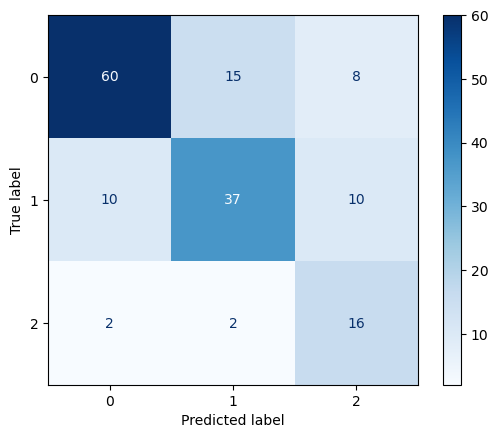

In [23]:
# Visualização da matriz de confusão
confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay.from_predictions(y_test, yPred_lr, cmap='Blues')
plt.show()


In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.72      0.77        83
           1       0.69      0.65      0.67        57
           2       0.47      0.80      0.59        20

    accuracy                           0.71       160
   macro avg       0.66      0.72      0.68       160
weighted avg       0.74      0.71      0.71       160



A Regressão Logística apresentou desempenho moderado, com acurácia de 0,71 e F1-score macro de 0,68, indicando desempenho razoavelmente equilibrado entre as classes.

O melhor desempenho foi observado na classe 0, enquanto a classe 2 apresenta maior recall, porém com precisão mais baixa, sugerindo maior incidência de falsos positivos para essa classe.

O modelo apresenta maior dificuldade em distinguir a classe minoritária, sugerindo que as fronteiras de decisão entre as notas de 'Recuperação' e 'Reprovado' são sutis."

## 6.3 - Validação Cruzada (Cross validation) da Regressão Logística

Foi aplicada validação cruzada K-Fold para aumentar a robustez do modelo
e reduzir o risco de overfitting.

Durante o treinamento, o solver *lbfgs* não convergiu com 2.000 iterações.
O ajuste do parâmetro `max_iter` para 10.000 permitiu a convergência da
função de custo, garantindo estabilidade no processo de otimização.


In [25]:
cv_lr = cross_val_score(
    log_reg,
    X,
    y,
    cv=5,
    scoring='f1_macro'
)

print("F1 Macro CV (LogReg): ", cv_lr.mean())

F1 Macro CV (LogReg):  0.6943004850518446


O F1-score macro médio de 0,69 ao longo das dobras da validação cruzada
indica um desempenho consistente do modelo, com capacidade razoável de
generalização e tratamento equilibrado das classes.

Essa métrica é especialmente relevante neste contexto devido ao
desbalanceamento das classes, fornecendo uma avaliação mais informativa
do que a acurácia isolada.


# 7 - Modelo 2: *RandomForest*

O Random Forest foi aplicado por sua capacidade de modelar relações não
lineares e interações entre variáveis, além de sua robustez a outliers
e ao desbalanceamento de classes.



## 7.1 - Treinamento do modelo *Random Forest*

In [26]:
# Treinamento

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight = 'balanced'
    )

# Treinar o modelo
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

O parâmetro `random_state` foi fixado para garantir reprodutibilidade
dos resultados, permitindo comparações consistentes entre execuções
e entre diferentes modelos.

## 7.2 - Avaliação do *Random Forest*

In [29]:
# Avaliação

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1-score (macro):", f1_score(y_test, y_pred_rf, average='macro'))


Accuracy: 0.71875
F1-score (macro): 0.6634717424191107


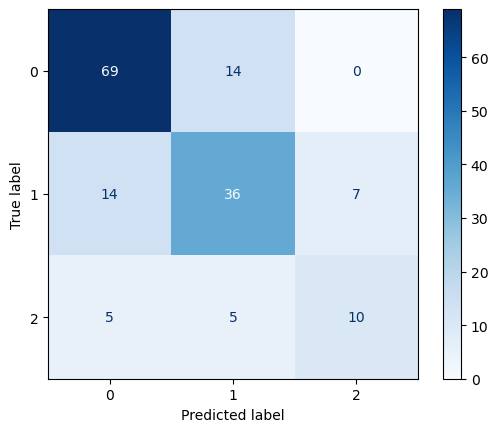

In [30]:
# Visualização do resultado da matriz de confusão
confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap='Blues')
plt.show()


In [31]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.78      0.83      0.81        83
           1       0.65      0.63      0.64        57
           2       0.59      0.50      0.54        20

    accuracy                           0.72       160
   macro avg       0.68      0.65      0.66       160
weighted avg       0.71      0.72      0.72       160



O Random Forest apresentou desempenho semelhante ao modelo baseline,
com acurácia de 0,72 e F1-score macro de 0,66.

Observa-se melhor desempenho na classe 0, enquanto a classe 2 apresenta
redução no recall, indicando maior dificuldade do modelo em identificar
corretamente alunos nessa categoria.

Em comparação com a regressão logística, o ganho de acurácia não se traduz
em melhoria consistente no desempenho macro entre as classes.

## 7.3 - Validação Cruzada (Crox validation) para o *Random Forest*

In [32]:
cv_rf = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='f1_macro'
)

print("F1 Macro CV (Random Forest): ", cv_rf.mean())

F1 Macro CV (Random Forest):  0.695309719509964


O F1-score macro médio de 0,70 obtido pelo Random Forest na validação cruzada indica
um desempenho consistente entre as dobras e boa capacidade de
generalização no tratamento das classes.

Esse desempenho é semelhante à regressão logística, o que
reforça a proximidade entre os modelos avaliados.


# 8 - Comparação dos modelos

Os modelos foram comparados utilizando:
- F1-score macro
- Resultados da validação cruzada
- Matriz de confusão

Essa abordagem permite avaliar não apenas a acurácia geral,
mas também o desempenho de cada classe de risco acadêmico.


In [44]:
importancias = pd.DataFrame({
    'feature': X.columns,
    'importancia': rf.feature_importances_
}).sort_values(by='importancia', ascending=False)

importancias

,feature,importancia
16,media_freq_b1_b3,0.194145
15,media_nota_b1_b3,0.151262
11,freq_b2,0.077943
12,freq_b3,0.075413
3,prova_b3,0.066717
10,freq_b1,0.065115
1,prova_b1,0.053982
17,slope_nota,0.037875
2,prova_b2,0.037772
18,var_nota,0.037381


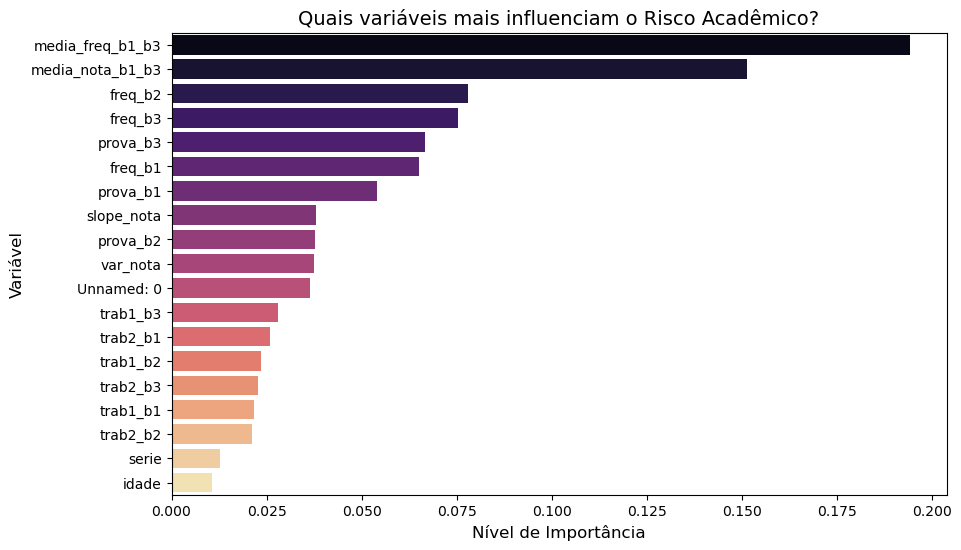

In [47]:
# Visualizando as variáveis com maior importância
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importancias,
    x='importancia',
    y='feature',
    palette='magma'
)
plt.title('Quais variáveis mais influenciam o Risco Acadêmico?', fontsize=14)
plt.xlabel('Nível de Importância', fontsize=12)
plt.ylabel('Variável', fontsize=12)
plt.show()

Resumo dos resultados de importância:

✔ media_freq_b1_b3 (0.20) identificado como principal preditor.

✔ media_nota_b1_b3 (0.16) identificado como a segunda métrica de maior importância. Indica que o desempenho acumulado pode ser mais útil que a nota pontual dos bimestres para prever a situação acadêmica final dos alunos.

✔ Frequência individual por bimestre exibiu maior importância que provas isoladas.

✔ Trabalhos têm menor impacto, o que pode ser causado pela baixa contribuição deles na nota final.

✔ Idade e série se mostram quase irrelevantes.

Embora ambos os modelos tenham apresentado métricas similares, a Regressão Logística se mostrou preferível por ser um modelo mais simples e computacionalmente eficiente para este caso. No entanto, o Random Forest permitiu identificar que a 'Nota do 3º Bimestre' (por exemplo) é o principal indicador de risco, oferecendo um insight valioso para intervenções pedagógicas precoces."

# 9 - Interpretação dos Resultados

Os resultados indicam que:
- O desempenho nas provas dos primeiros bimestres
- A frequência escolar

são fatores determinantes para a situação final do aluno.

Essas informações podem ser utilizadas para:
- Identificar alunos em risco no 3º bimestre
- Direcionar ações de reforço escolar
- Avaliar o impacto das atividades avaliativas

A análise de importância das variáveis revelou que as médias acumuladas (criadas via feature engineering) são os principais preditores de risco. A frequência escolar apresentou uma importância agregada superior às notas individuais de provas e trabalhos.

Conclusão Pedagógica: O modelo sugere que intervenções baseadas na assiduidade do aluno desde o segundo bimestre podem ser mais eficazes para prevenir o risco acadêmico do que focar apenas na recuperação de notas baixas no final do ano.
Porém, a frequência obteve um melhor desempenho por se tratar de um critério institucional excludente para aprovação, assim o modelo aprende como um forte indicador de reprovação, um atalho na definição de aprovação. Por isso, convém explorar melhor se aqui a frequência tem alguma relação com as notas, o que faria mais sentido no caso de uma intervenção pedagógica.


# 9 - Interpretação dos Resultados

Os modelos de Regressão Logística Multiclasse e Random Forest apresentaram desempenhos
semelhantes, com valores próximos de F1-score macro tanto no conjunto de teste quanto
na validação cruzada, indicando boa capacidade de generalização e estabilidade entre
as classes de risco acadêmico.

A Regressão Logística demonstrou desempenho ligeiramente superior na identificação
da classe minoritária, apresentando maior equilíbrio entre precisão e recall, o que
é desejável em um cenário de previsão de risco, no qual erros de classificação podem
impactar diretamente ações pedagógicas.

O Random Forest, por sua vez, apresentou maior capacidade de capturar padrões não
lineares e permitiu a interpretação das variáveis mais relevantes para a tomada de
decisão, sendo especialmente útil para análises exploratórias e comunicação com
stakeholders não técnicos.

De forma geral, os resultados indicam que o risco acadêmico está mais associado ao
desempenho consolidado ao longo dos três primeiros bimestres, representado pelas
médias de notas e frequência, do que a avaliações isoladas. A frequência escolar
destacou-se como um forte preditor por se tratar de um critério institucional
excludente para aprovação.

Esses achados reforçam o potencial do modelo como uma ferramenta de apoio à decisão,
permitindo identificar alunos em risco ainda no 3º bimestre e direcionar intervenções
pedagógicas de forma antecipada e baseada em dados.




# 10 - Explorações sobre frequência

In [49]:
# Importação do dataset original
df_raw=pd.read_csv("../data/raw/dados_academicos.csv")
df.head()

,Unnamed: 0,prova_b1,prova_b2,prova_b3,trab1_b1,trab1_b2,trab1_b3,trab2_b1,trab2_b2,trab2_b3,freq_b1,freq_b2,freq_b3,idade,serie,media_nota_b1_b3,media_freq_b1_b3,slope_nota,var_nota,resultado_final
0,0,6.5,5.9,4.8,0.2,0.1,0.7,0.3,0.3,0.8,77.7,84.2,51.0,13,6,6.533333,70.966667,-0.7,0.163333,0
1,1,3.8,7.0,3.7,0.3,0.1,0.7,0.1,0.3,0.3,75.2,94.1,88.6,14,7,5.433333,85.966667,0.5,2.963333,1
2,2,5.9,6.8,5.6,0.2,0.9,0.1,0.4,0.1,0.5,59.7,60.2,58.5,11,6,6.833333,59.466667,-0.3,0.723333,0
3,3,6.0,3.8,3.6,0.4,0.2,0.9,0.3,0.7,1.0,92.9,93.7,52.2,13,6,5.633333,79.600000,-1.2,1.013333,0
4,4,5.1,3.7,7.7,0.1,0.8,0.6,0.7,0.0,0.7,83.8,53.0,82.7,13,7,6.466667,73.166667,3.1,5.303333,2


## 10.1 - Análise de correlação

In [50]:
# Correlação de Pearson entre frequência acumulada e nota final
correlacao = df_raw['frequencia_final'].corr(df_raw['nota_final'])
print(f"Correlação entre Presença e Nota: {correlacao:.2f}")


Correlação entre Presença e Nota: 0.05


## 10.2 - Visualização da dispersão

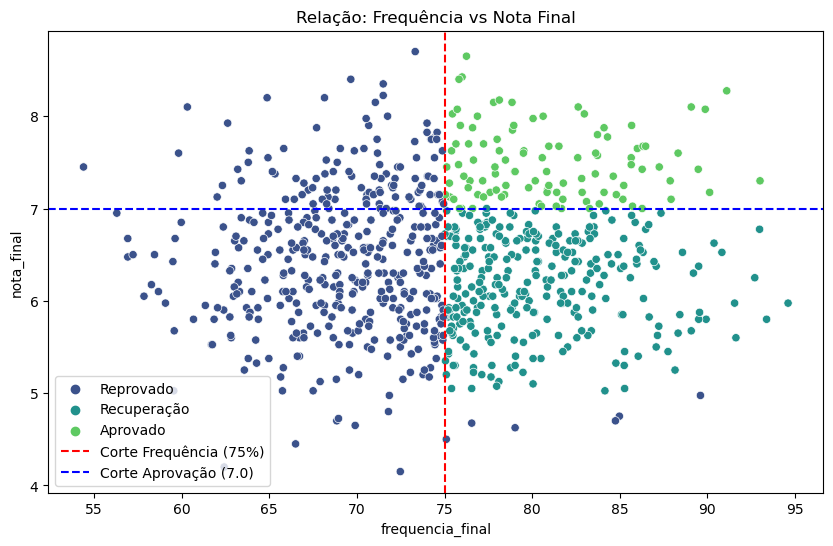

In [51]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_raw, x='frequencia_final', y='nota_final', hue='resultado_final', palette='viridis')
plt.axvline(75, color='red', linestyle='--', label='Corte Frequência (75%)')
plt.axhline(7, color='blue', linestyle='--', label='Corte Aprovação (7.0)')
plt.title('Relação: Frequência vs Nota Final')
plt.legend()
plt.show()


Observa-se que a frequência apresenta correlação muito baixa com as notas finais
(cerca de 0,05), apesar de possuir alta importância no modelo. Esse comportamento
é explicado, em parte, pelas regras institucionais de aprovação, que exigem um
mínimo de 75% de frequência, tornando essa variável um critério excludente.

A análise de dispersão não indica a presença de um padrão claro entre frequência
e nota final, com os dados distribuídos de forma homogênea ao longo do espaço
amostral. Esse comportamento decorre da natureza sintética do dataset, construído
para garantir aleatoriedade controlada e distribuição aproximadamente normal das
variáveis.


# 11 - Limitações e Análise de Casualidade

Os dados utilizados neste projeto são sintéticos e foram gerados com distribuições
estatísticas controladas, o que limita a inferência de relações causais reais entre
as variáveis.

Embora o modelo tenha atribuído alta importância à frequência escolar, análises
anteriores indicaram ausência de correlação significativa entre frequência e nota
final. Esse comportamento reflete o fato de que a frequência atua como um critério
institucional excludente na rotulagem das classes, sendo aprendida pelo modelo como
um preditor matemático, e não necessariamente pedagógico.

Em um cenário com dados reais, seria esperado observar uma correlação positiva entre
frequência e desempenho acadêmico, refletindo o impacto do engajamento em sala de
aula no aprendizado.

Por fim, este modelo não substitui a avaliação pedagógica humana, devendo ser
interpretado como uma ferramenta de apoio à decisão. Apesar dessas limitações, o
projeto demonstra um pipeline completo de Data Science aplicado a um problema real.


# 12 - Conclusão

Este notebook apresentou:
- Uma abordagem de modelagem multiclasse com foco em risco acadêmico;
- A comparação entre modelos interpretáveis e métodos ensemble;
- Uma avaliação robusta por meio de validação cruzada;
- A interpretação dos resultados orientada ao contexto educacional.

O sistema proposto demonstra potencial como base para soluções de
análise preditiva no ambiente escolar, atuando como ferramenta de
apoio à tomada de decisão pedagógica.


# 13 - Próximos Passos

No próximo notebook, os resultados do modelo serão utilizados para:
- Construção de um score de risco acadêmico por aluno;
- Geração de outputs consolidados para visualização em dashboard;
- Apoio à coordenação pedagógica na identificação e priorização de alunos em risco.

Essa etapa conecta a modelagem preditiva à aplicação prática,
viabilizando o uso dos resultados no processo de tomada de decisão.
